In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

from sklearn.decomposition import PCA

import pickle
import os

In [2]:
os.makedirs("models", exist_ok=True)
os.makedirs("reports", exist_ok=True)
os.makedirs("data", exist_ok=True)

print("Folders Ready")

Folders Ready


In [3]:
df = pd.read_csv(
    "data/cleaned_customers.csv"
)

print(df.shape)

df.head()

(53503, 23)


,Customer ID,Age,Gender,Marital Status,Education Level,Geographic Information,Occupation,Income Level,Behavioral Data,Purchase History,...,Premium Amount,Policy Type,Customer Preferences,Preferred Communication Channel,Preferred Contact Time,Preferred Language,Segmentation Group,Age_Group,Income_Level,Spending_Category
0,84966,23,0,1,0,22,3,70541,4,270,...,2749,2,0,1,0,0,4,3,2,2
1,95568,26,1,4,2,10,5,54168,4,942,...,1966,2,2,1,3,1,4,0,2,0
2,10544,29,0,3,0,27,3,73899,4,387,...,4413,2,0,2,2,2,2,0,2,0
3,77033,20,1,0,1,28,3,63381,4,582,...,4342,1,4,1,1,1,2,3,2,0
4,88160,25,0,2,1,34,5,38794,0,630,...,1276,1,0,4,4,0,1,3,1,2


In [4]:
features = [
    "Age",
    "Income Level",
    "Coverage Amount",
    "Premium Amount"
]

X = df[features]

X.head()

,Age,Income Level,Coverage Amount,Premium Amount
0,23,70541,366603,2749
1,26,54168,780236,1966
2,29,73899,773926,4413
3,20,63381,787815,4342
4,25,38794,366506,1276


In [5]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print(X_scaled.shape)

(53503, 4)


In [6]:
inertia = []

k_values = range(2, 11)

for k in k_values:

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(X_scaled)

    inertia.append(
        kmeans.inertia_
    )

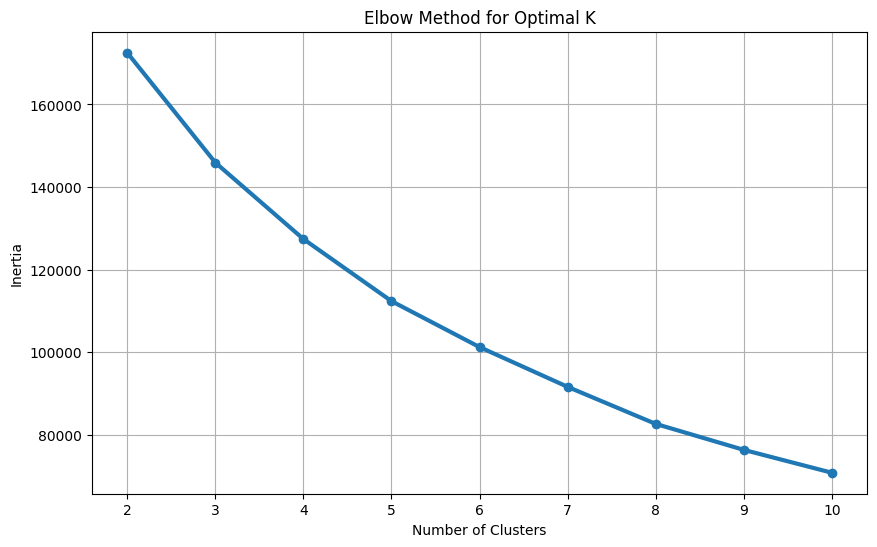

In [7]:
plt.figure(figsize=(10,6))

plt.plot(
    k_values,
    inertia,
    marker="o",
    linewidth=3
)

plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")

plt.title(
    "Elbow Method for Optimal K"
)

plt.grid(True)

plt.show()
#The elbow point indicates the optimal number of clusters.

#After this point, additional clusters provide
#minimal improvement.

In [1]:
kmeans = KMeans(
    n_clusters=5,
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(X_scaled)

df["Cluster"] = clusters

print("Clustering Completed")

NameError: name 'KMeans' is not defined

In [4]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

import pickle
import os

In [5]:
df = pd.read_csv("data/cleaned_customers.csv")

features = [
    "Age",
    "Income Level",
    "Coverage Amount",
    "Premium Amount"
]

X = df[features]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [6]:
kmeans = KMeans(
    n_clusters=5,
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(X_scaled)

df["Cluster"] = clusters

print("Clustering Completed")

Clustering Completed


In [7]:
cluster_profile = df.groupby("Cluster")[[
    "Age",
    "Income Level",
    "Coverage Amount",
    "Premium Amount"
]].mean()

cluster_profile.round(2)

,Age,Income Level,Coverage Amount,Premium Amount
Cluster,,,,
0,44.96,79841.22,785661.55,1780.72
1,33.46,50346.87,477680.22,3866.99
2,44.62,82097.21,260623.08,1590.68
3,34.57,121479.80,471304.93,3777.04
4,61.90,81235.16,482280.00,3868.27


In [8]:
df.to_csv(
    "data/clustered_customers.csv",
    index=False
)

In [9]:
import pickle

with open(
    "models/kmeans_model.pkl",
    "wb"
) as file:
    pickle.dump(kmeans, file)

In [10]:
cluster_profile.to_csv(
    "reports/cluster_profile.csv"
)